<a href="https://colab.research.google.com/github/shakthyy30/shakthyy-codebooster-2026/blob/main/Weather_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests

# API details
API_KEY ='222f93de1c6ba3d676159ab0a6871742'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Mumbai',
    'Bangalore',
    'Chennai',
    'Hyderabad',
    'Kolkata',
    'Pune',
    'Jaipur'
]


# Function to fetch weather data
def fetch_weather(city, API_KEY):

    """
    Fetch current weather data for a given city.
    Returns weather details dictionary or None on failure.
    """

    params = {
        'q': city,
        'appid': API_KEY,
        'units': 'metric'
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=10
        )

        if response.status_code == 200:

            data = response.json()

            return {
                'city': data['name'],
                'temperature': data['main']['temp'],
                'description': data['weather'][0]['description'],
                'icon': data['weather'][0]['icon'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'visibility': data.get('visibility', 0),
                'sunrise': data['sys']['sunrise'],
                'sunset': data['sys']['sunset']
            }

        else:

            print(f"Error fetching weather data for {city}")
            print(f"Status code: {response.status_code}")

            return None

    except requests.exceptions.RequestException as e:

        print(f"Request failed: {e}")

        return None


# Call API for all cities
print("Calling Weather API...\n")

weather_records = []

for city in CITIES:

    print(f"Fetching weather for {city}...", end=' ')

    record = fetch_weather(city, API_KEY)

    if record:

        weather_records.append(record)

        print(
            f"{record['temperature']}°C, "
            f"{record['description']}"
        )

    else:

        print("Failed")


# Final Output
print("\nWeather Records:\n")

for record in weather_records:
    print(record)

Calling Weather API...

Fetching weather for Mumbai... 33.99°C, smoke
Fetching weather for Bangalore... 31.06°C, scattered clouds
Fetching weather for Chennai... 33.46°C, scattered clouds
Fetching weather for Hyderabad... 37.23°C, scattered clouds
Fetching weather for Kolkata... 32.97°C, haze
Fetching weather for Pune... 35.22°C, clear sky
Fetching weather for Jaipur... 35.62°C, haze

Weather Records:

{'city': 'Mumbai', 'temperature': 33.99, 'description': 'smoke', 'icon': '50d', 'humidity': 55, 'wind_speed': 4.63, 'pressure': 1008, 'visibility': 5000, 'sunrise': 1780101053, 'sunset': 1780148500}
{'city': 'Bengaluru', 'temperature': 31.06, 'description': 'scattered clouds', 'icon': '03d', 'humidity': 56, 'wind_speed': 4.47, 'pressure': 1007, 'visibility': 8000, 'sunrise': 1780100549, 'sunset': 1780146721}
{'city': 'Chennai', 'temperature': 33.46, 'description': 'scattered clouds', 'icon': '03d', 'humidity': 60, 'wind_speed': 4.12, 'pressure': 1005, 'visibility': 6000, 'sunrise': 17800

In [ ]:
import pandas as pd

df = pd.DataFrame(weather_records)

print(df.head())

        city  temperature       description icon  humidity  wind_speed  \
0     Mumbai        33.99             smoke  50d        55        4.63   
1  Bengaluru        31.06  scattered clouds  03d        56        4.47   
2    Chennai        33.46  scattered clouds  03d        60        4.12   
3  Hyderabad        37.23  scattered clouds  03d        28        7.20   
4    Kolkata        32.97              haze  50d        62        2.06   

   pressure  visibility     sunrise      sunset  
0      1008        5000  1780101053  1780148500  
1      1007        8000  1780100549  1780146721  
2      1005        6000  1780099896  1780146090  
3      1006        6000  1780099880  1780146972  
4      1002        4000  1780096927  1780145174  


In [ ]:
import pandas as pd

# Convert weather_records to a DataFrame
df = pd.DataFrame(weather_records)

# ==========================
# ETL CLEANING
# ==========================

print("Before Cleaning:")
print(df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# Validate temperature
df = df[df['temperature'].between(-50, 60)]

# Validate humidity
df = df[df['humidity'].between(0, 100)]

# Validate wind speed
df = df[df['wind_speed'] >= 0]

# Validate pressure
df = df[df['pressure'] > 0]

# Validate visibility
df = df[df['visibility'] >= 0]

print("\nAfter Cleaning:")
print(df.shape)

# ==========================
# COMPUTE HEAT INDEX
# ==========================

df['heat_index'] = (
    df['temperature']
    + (0.1 * df['humidity'])
)

print("\nData with Heat Index:")
print(
    df[['city',
        'temperature',
        'humidity',
        'heat_index']]
)


Before Cleaning:
(7, 10)

Missing Values:
city           0
temperature    0
description    0
icon           0
humidity       0
wind_speed     0
pressure       0
visibility     0
sunrise        0
sunset         0
dtype: int64

After Cleaning:
(7, 10)

Data with Heat Index:
        city  temperature  humidity  heat_index
0     Mumbai        33.99        55       39.49
1  Bengaluru        31.06        56       36.66
2    Chennai        33.46        60       39.46
3  Hyderabad        37.23        28       40.03
4    Kolkata        32.97        62       39.17
5       Pune        35.22        28       38.02
6     Jaipur        35.62        28       38.42


In [ ]:
df.to_csv("weather_cleaned.csv", index=False)

print("Cleaned CSV saved successfully!")

Cleaned CSV saved successfully!


In [ ]:
import sqlite3

# Create database connection
conn = sqlite3.connect("weather.db")

# Store dataframe into SQLite table
df.to_sql(
    "weather_data",
    conn,
    if_exists="replace",
    index=False
)

print("Data stored successfully in SQLite!")

Data stored successfully in SQLite!


In [ ]:
query = "SELECT * FROM weather_data"

import pandas as pd
pd.read_sql(query, conn)

,city,temperature,description,icon,humidity,wind_speed,pressure,visibility,sunrise,sunset,heat_index
0,Mumbai,33.99,smoke,50d,55,4.63,1008,5000,1780101053,1780148500,39.49
1,Bengaluru,31.06,scattered clouds,03d,56,4.47,1007,8000,1780100549,1780146721,36.66
2,Chennai,33.46,scattered clouds,03d,60,4.12,1005,6000,1780099896,1780146090,39.46
3,Hyderabad,37.23,scattered clouds,03d,28,7.20,1006,6000,1780099880,1780146972,40.03
4,Kolkata,32.97,haze,50d,62,2.06,1002,4000,1780096927,1780145174,39.17
5,Pune,35.22,clear sky,01d,28,6.05,1007,10000,1780100865,1780148204,38.02
6,Jaipur,35.62,haze,50d,28,3.60,1005,5000,1780099416,1780148711,38.42


In [ ]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect("weather.db")

print("========== WEATHER INSIGHTS ==========\n")

# 1. Hottest City
print("1. Hottest City")
query1 = """
SELECT city, temperature
FROM weather_data
ORDER BY temperature DESC
LIMIT 1;
"""
print(pd.read_sql(query1, conn))
print()

# 2. Most Humid City
print("2. Most Humid City")
query2 = """
SELECT city, humidity
FROM weather_data
ORDER BY humidity DESC
LIMIT 1;
"""
print(pd.read_sql(query2, conn))
print()

# 3. Highest Wind Speed City
print("3. Highest Wind Speed City")
query3 = """
SELECT city, wind_speed
FROM weather_data
ORDER BY wind_speed DESC
LIMIT 1;
"""
print(pd.read_sql(query3, conn))
print()

# 4. Average Temperature
print("4. Average Temperature")
query4 = """
SELECT ROUND(AVG(temperature),2) AS Average_Temperature
FROM weather_data;
"""
print(pd.read_sql(query4, conn))
print()

# 5. Average Humidity
print("5. Average Humidity")
query5 = """
SELECT ROUND(AVG(humidity),2) AS Average_Humidity
FROM weather_data;
"""
print(pd.read_sql(query5, conn))
print()

# 6. Top 3 Hottest Cities
print("6. Top 3 Hottest Cities")
query6 = """
SELECT city, temperature
FROM weather_data
ORDER BY temperature DESC
LIMIT 3;
"""
print(pd.read_sql(query6, conn))
print()

# 7. Cities with Heat Index > 35
print("7. Cities with Heat Index > 35")
query7 = """
SELECT city, heat_index
FROM weather_data
WHERE heat_index > 35;
"""
print(pd.read_sql(query7, conn))
print()

print("========== END OF REPORT ==========")

# Close connection
conn.close()

========== WEATHER INSIGHTS ==========

1. Hottest City
        city  temperature
0  Hyderabad        37.23

2. Most Humid City
      city  humidity
0  Kolkata        62

3. Highest Wind Speed City
        city  wind_speed
0  Hyderabad         7.2

4. Average Temperature
   Average_Temperature
0                34.22

5. Average Humidity
   Average_Humidity
0             45.29

6. Top 3 Hottest Cities
        city  temperature
0  Hyderabad        37.23
1     Jaipur        35.62
2       Pune        35.22

7. Cities with Heat Index > 35
        city  heat_index
0     Mumbai       39.49
1  Bengaluru       36.66
2    Chennai       39.46
3  Hyderabad       40.03
4    Kolkata       39.17
5       Pune       38.02
6     Jaipur       38.42

========== END OF REPORT ==========


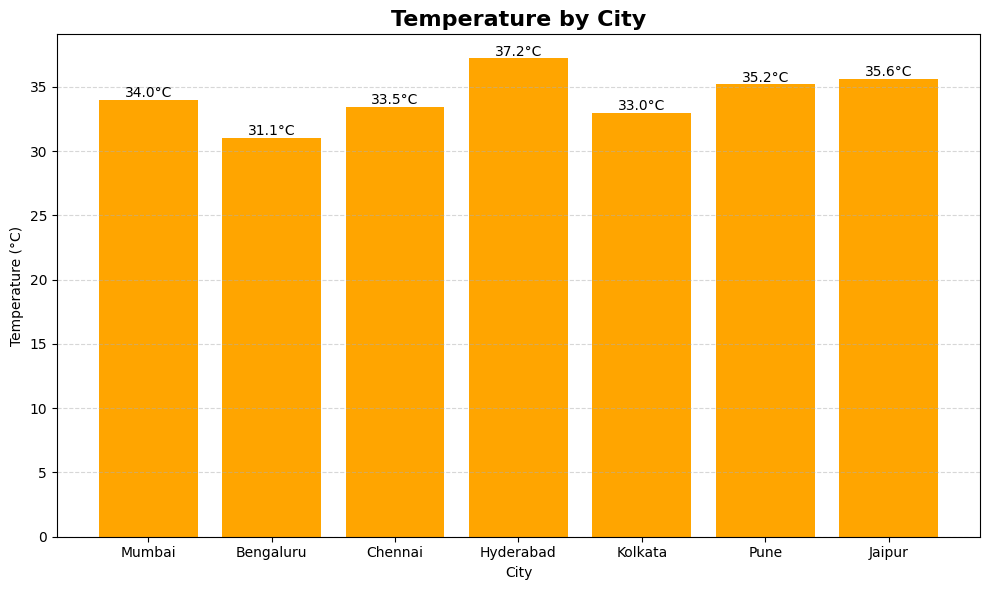

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    df['city'],
    df['temperature'],
    color='orange'
)

plt.title('Temperature by City', fontsize=16, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}°C',
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

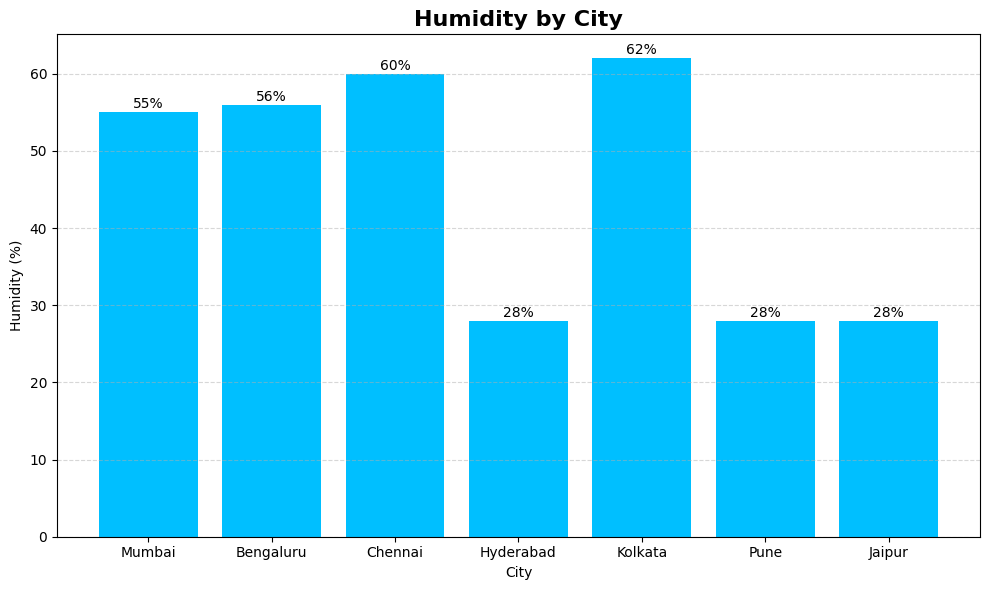

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    df['city'],
    df['humidity'],
    color='deepskyblue'
)

plt.title('Humidity by City', fontsize=16, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Humidity (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.0f}%',
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

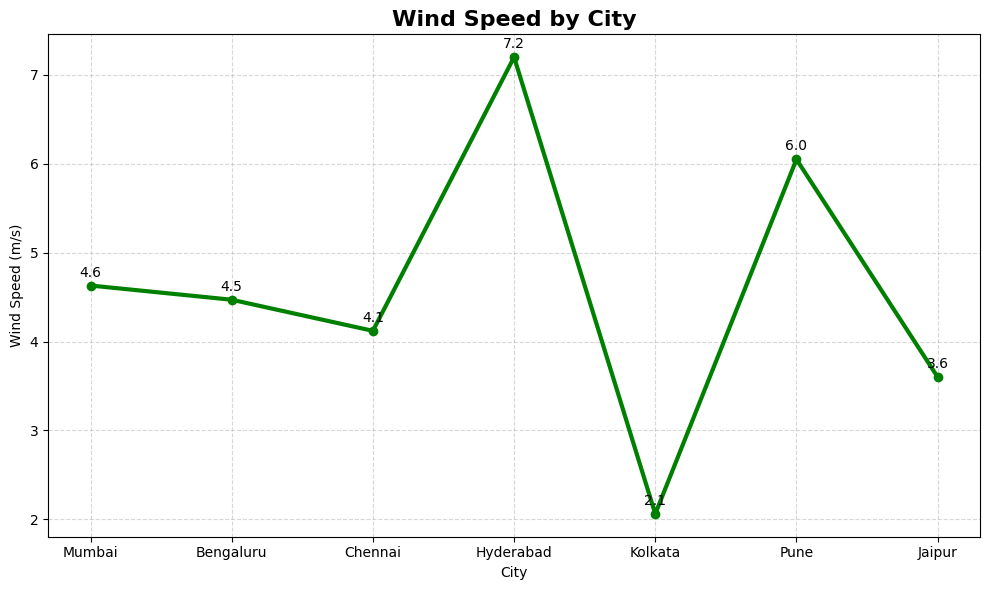

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    df['city'],
    df['wind_speed'],
    marker='o',
    linewidth=3,
    color='green'
)

plt.title('Wind Speed by City', fontsize=16, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Wind Speed (m/s)')

for i, value in enumerate(df['wind_speed']):
    plt.text(
        i,
        value + 0.1,
        f'{value:.1f}',
        ha='center'
    )

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features (Input)
X = df[['temperature', 'wind_speed']]

# Target (Output)
y = df['humidity']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Model Performance")
print("-----------------")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

# Example Prediction
temperature = 30
wind_speed = 5

predicted_humidity = model.predict(
    [[temperature, wind_speed]]
)

print("\nPrediction")
print("-----------")
print(f"Temperature : {temperature} °C")
print(f"Wind Speed  : {wind_speed} m/s")
print(f"Predicted Humidity : {predicted_humidity[0]:.2f}%")

Model Performance
-----------------
MAE : 2.0500000000000007
R2 Score : -16.021600000000014

Prediction
-----------
Temperature : 30 °C
Wind Speed  : 5 m/s
Predicted Humidity : 53.72%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Ensure 'heat_index' is in df, in case df was overwritten by a previous cell
# This line is added to handle cases where df might have been reset without 'heat_index'
# by other cells executed out of order.
df['heat_index'] = df['temperature'] + (0.1 * df['humidity'])

# Features (Input) - adding 'heat_index' to potentially improve prediction
X_new = df[['temperature', 'wind_speed', 'heat_index']]

# Target (Output)
y_new = df['humidity']

# Split dataset
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42
)

# Train Model
model_new = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_new.fit(X_train_new, y_train_new)

# Predictions
y_pred_new = model_new.predict(X_test_new)

# Evaluation
print("New Model Performance (with Heat Index)")
print("------------------------------------")
print("MAE :", mean_absolute_error(y_test_new, y_pred_new))
print("R2 Score :", r2_score(y_test_new, y_pred_new))

# Example Prediction with new features
temperature_new = 30
wind_speed_new = 5
# Calculate heat_index for the example prediction based on the example temperature and previously predicted humidity
# We use the predicted_humidity from the previous model as a placeholder for consistency, though in a real scenario
# you might use a sensible default or an average if predicting a single point without prior humidity.
heat_index_new = temperature_new + (0.1 * predicted_humidity[0])

predicted_humidity_new = model_new.predict(
    pd.DataFrame([[temperature_new, wind_speed_new, heat_index_new]], columns=X_new.columns)
)

print("\nNew Prediction")
print("---------------")
print(f"Temperature : {temperature_new} °C")
print(f"Wind Speed  : {wind_speed_new} m/s")
print(f"Heat Index  : {heat_index_new:.2f}")
print(f"Predicted Humidity : {predicted_humidity_new[0]:.2f}%")


New Model Performance (with Heat Index)
------------------------------------
MAE : 3.1700000000000017
R2 Score : -55.679200000000066

New Prediction
---------------
Temperature : 30 °C
Wind Speed  : 5 m/s
Heat Index  : 35.37
Predicted Humidity : 50.80%


Correlation Matrix:
             temperature  humidity  wind_speed  pressure  visibility  \
temperature     1.000000 -0.821324    0.590423  0.073197   -0.040025   
humidity       -0.821324  1.000000   -0.634547 -0.265508   -0.364581   
wind_speed      0.590423 -0.634547    1.000000  0.659963    0.565744   
pressure        0.073197 -0.265508    0.659963  1.000000    0.556022   
visibility     -0.040025 -0.364581    0.565744  0.556022    1.000000   
heat_index      0.581671 -0.013712    0.130090 -0.250289   -0.590013   

             heat_index  
temperature    0.581671  
humidity      -0.013712  
wind_speed     0.130090  
pressure      -0.250289  
visibility    -0.590013  
heat_index     1.000000  


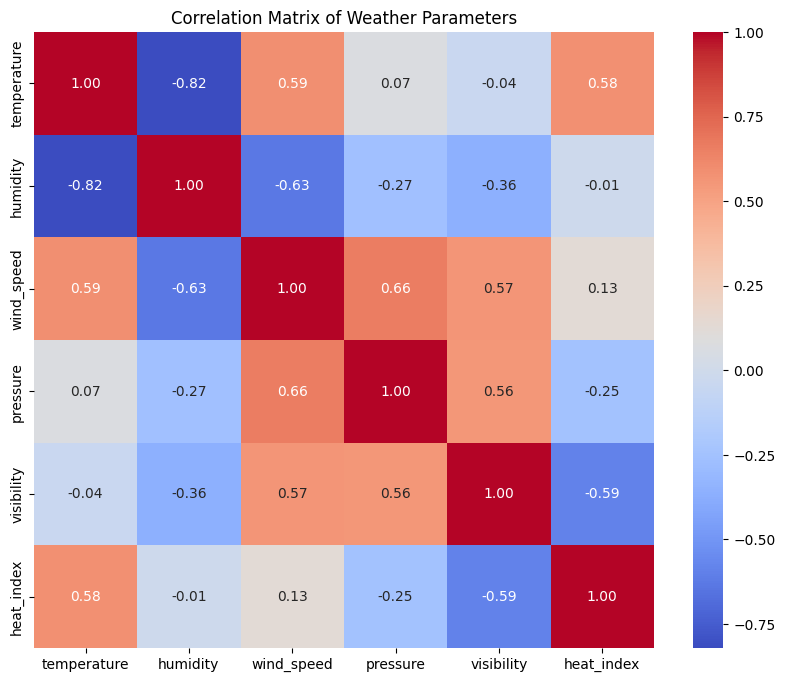


Correlation of Features with Humidity:
humidity       1.000000
heat_index    -0.013712
pressure      -0.265508
visibility    -0.364581
wind_speed    -0.634547
temperature   -0.821324
Name: humidity, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant numerical columns for correlation analysis
correlation_data = df[['temperature', 'humidity', 'wind_speed', 'pressure', 'visibility', 'heat_index']]

# Calculate the correlation matrix
corr_matrix = correlation_data.corr()

print("Correlation Matrix:")
print(corr_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Weather Parameters')
plt.show()

print("\nCorrelation of Features with Humidity:")
print(corr_matrix['humidity'].sort_values(ascending=False))